# Regression Model on Car Price Prediction

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the Dataset
df = pd.read_csv('ford.csv')
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


## 2. Exploratory Data Analysis

In [3]:
# Shape of the dataset
row, col = df.shape
print(f"The dataset has {row} rows and {col} columns")

The dataset has 17966 rows and 9 columns


In [4]:
# What's column the dataset has and what's their type?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [5]:
# Is there any missing values?
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [6]:
# Is there any duplicate values?
df.duplicated().sum()

154

In [7]:
# Summary Statistics
df.describe().round(2)

,year,price,mileage,tax,mpg,engineSize
count,17966.00,17966.00,17966.00,17966.00,17966.00,17966.00
mean,2016.87,12279.53,23362.61,113.33,57.91,1.35
std,2.05,4741.34,19472.05,62.01,10.13,0.43
min,1996.00,495.00,1.00,0.00,20.80,0.00
25%,2016.00,8999.00,9987.00,30.00,52.30,1.00
50%,2017.00,11291.00,18242.50,145.00,58.90,1.20
75%,2018.00,15299.00,31060.00,145.00,65.70,1.50
max,2060.00,54995.00,177644.00,580.00,201.80,5.00


Text(0.5, 1.0, 'Target Variable(price) Distribution')

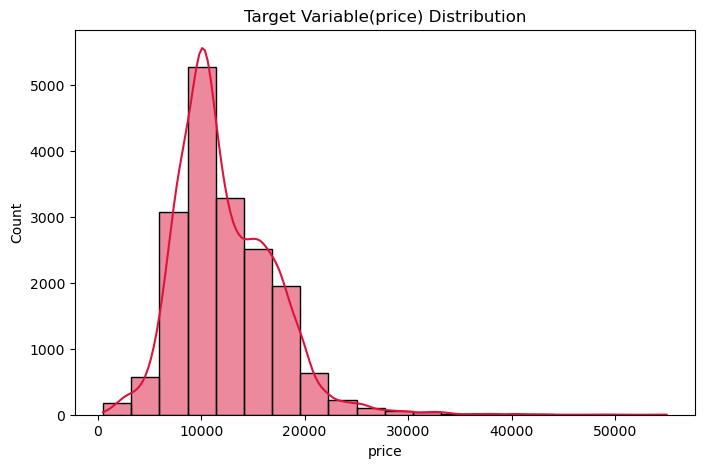

In [8]:
# Target Varibale Distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['price'], bins=20, kde=True, color='crimson')
ax.set_title("Target Variable(price) Distribution")

In [9]:
# Check Correlation
df.corr(numeric_only=True)

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.636009,-0.707818,0.298506,-0.022967,-0.137311
price,0.636009,1.000000,-0.530659,0.406857,-0.346419,0.411178
mileage,-0.707818,-0.530659,1.000000,-0.260451,0.120075,0.215035
tax,0.298506,0.406857,-0.260451,1.000000,-0.502980,0.184363
mpg,-0.022967,-0.346419,0.120075,-0.502980,1.000000,-0.260521
engineSize,-0.137311,0.411178,0.215035,0.184363,-0.260521,1.000000


Text(0.5, 1.0, 'Correlation of all features with price')

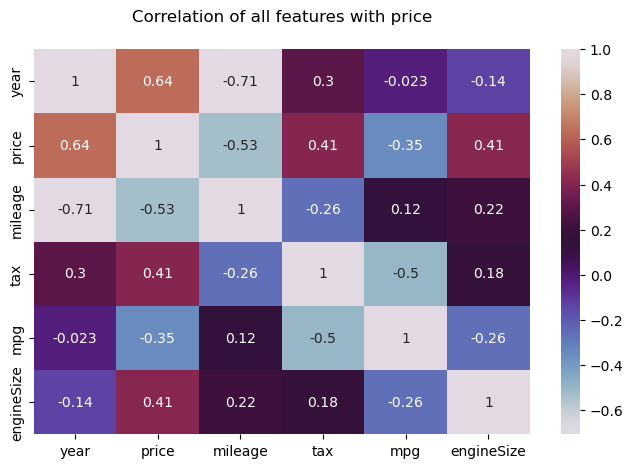

In [10]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), cmap='twilight', annot=True)
ax.set_title("Correlation of all features with price", pad=20)

<Axes: xlabel='price'>

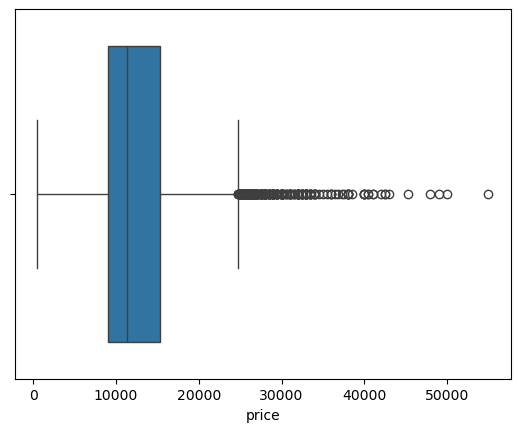

In [11]:
# Boxplot on Target Variable
sns.boxplot(data=df, x='price')

Text(0.5, 1.0, 'year vs price')

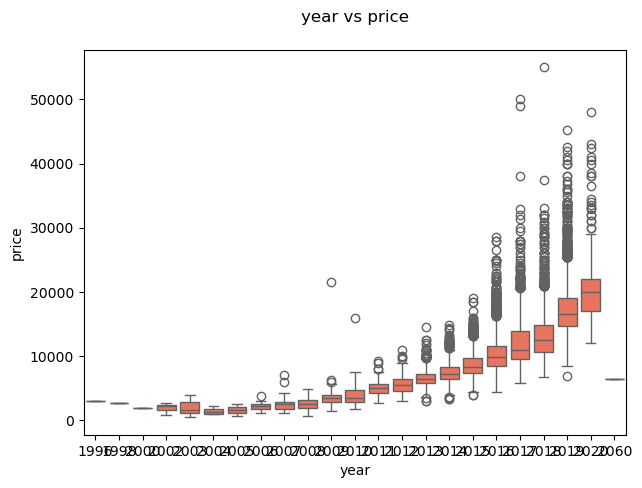

In [12]:
# Boxplot with Target Variable and Correlated Features
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='year', y='price', color='tomato')
ax.set_title("year vs price", pad=20)

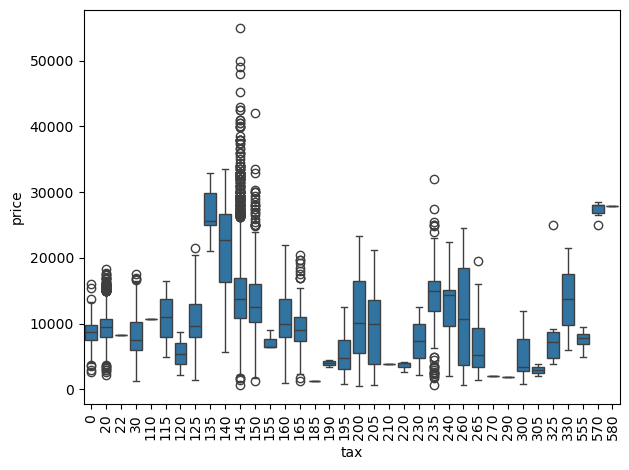

In [13]:
sns.boxplot(data=df, x='tax', y='price')
plt.xticks(rotation=90)
plt.tight_layout()

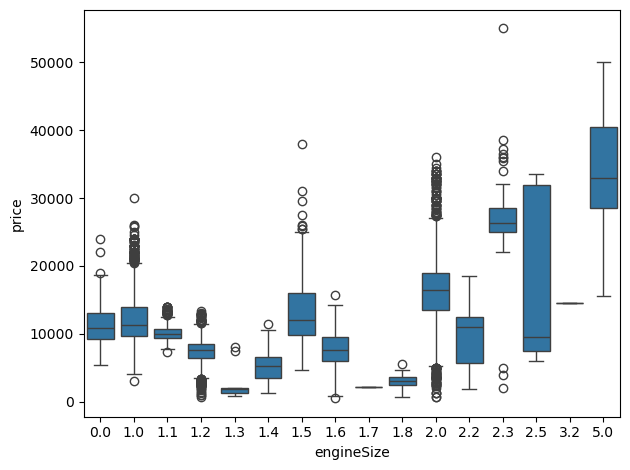

In [14]:
sns.boxplot(data=df, x='engineSize', y='price')
plt.tight_layout()

<Axes: xlabel='mileage', ylabel='price'>

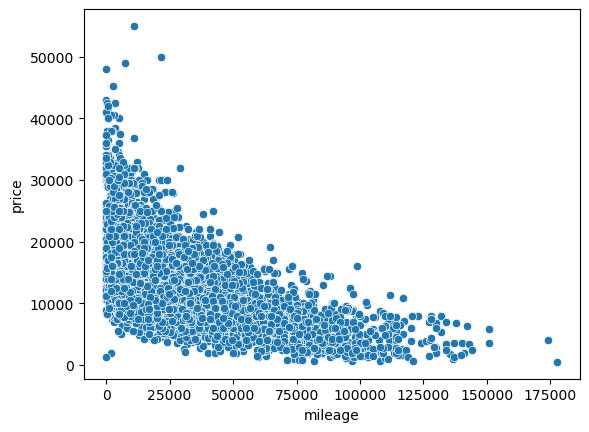

In [15]:
sns.scatterplot(data=df, x='mileage', y='price')

<Axes: xlabel='transmission', ylabel='price'>

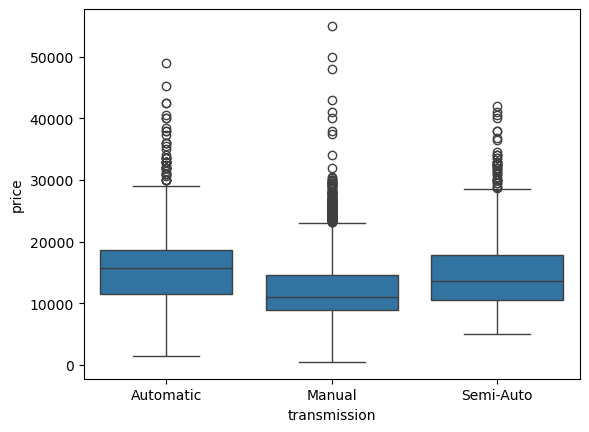

In [16]:
sns.boxplot(data=df, x='transmission', y='price')

<Axes: xlabel='fuelType', ylabel='price'>

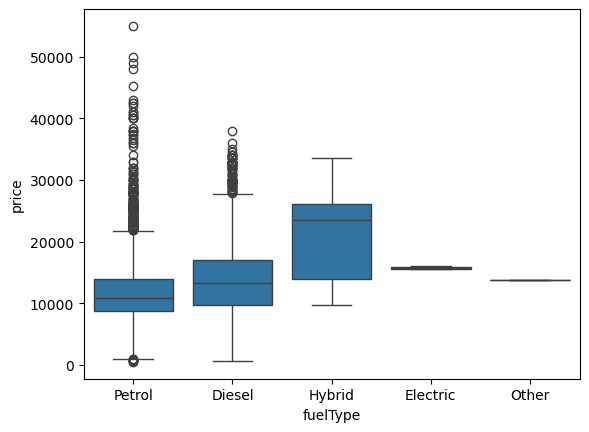

In [17]:
sns.boxplot(data=df, x='fuelType', y='price')

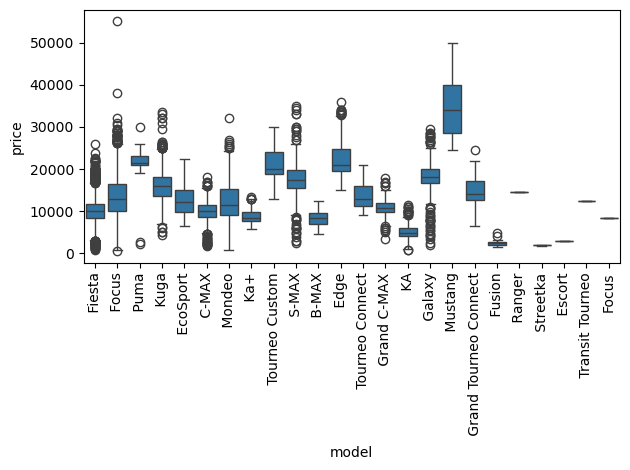

In [18]:
sns.boxplot(data=df, x='model', y='price')
plt.xticks(rotation=90)
plt.tight_layout()

<Axes: xlabel='mpg', ylabel='price'>

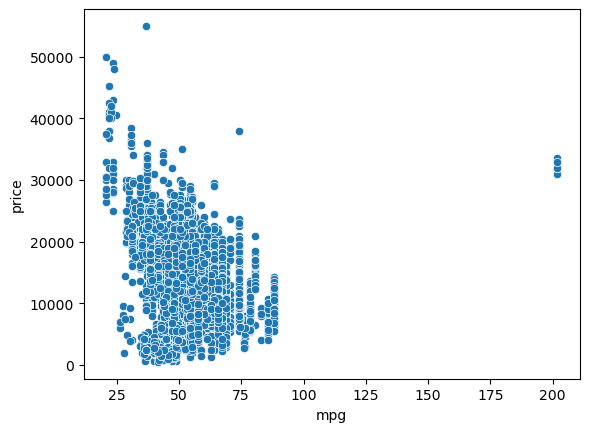

In [19]:
sns.scatterplot(data=df, x='mpg', y='price')

## 2. Data Cleaning

In [20]:
df.drop_duplicates(inplace=True)
df.shape

(17812, 9)

## 3. Feature Engineering

In [21]:
# Separate Independent and Dependent Variable
X = df.drop(columns='price', axis=1)
y = df['price']

In [22]:
X.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0


In [23]:
# Encoding Categorical Values
X_encode = pd.get_dummies(X, columns=['model', 'transmission', 'fuelType'], drop_first=True)
X_encode = X_encode.astype(int)
X_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,40700,30,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,7010,20,67,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,5007,145,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [24]:
# Feature Scaling
numerical_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
scaler = StandardScaler()
X_encode[numerical_cols] = scaler.fit_transform(X_encode[numerical_cols])
X_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,-0.382994,0.591380,-0.042291,-0.446958,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.554393,-0.736317,0.591380,-0.042291,-0.446958,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.067059,-0.562616,0.591380,-0.042291,-0.446958,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.041726,-0.665405,0.510777,-1.720193,-0.446958,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.041726,-1.127749,0.510777,-0.930592,-0.446958,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,-0.344061,0.591380,-1.029292,-0.446958,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.394942,0.891875,-1.343079,-0.042291,-0.446958,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.907608,-0.843071,-1.504284,0.944711,-0.446958,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.554393,-0.946220,0.510777,-0.042291,-0.446958,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


## 4. Train The Model

In [25]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encode, y, test_size=0.25, random_state=42)

In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## 5. Prediction of Test Data

In [27]:
y_pred = model.predict(X_test)
y_pred

array([22212.85771284, 15014.15081813, 16528.69091819, ...,
       10331.23576601, 10294.75388442,  9588.6688557 ])

In [28]:
y_train

17522    10500
16887     8279
6354     11000
10515    14410
1393     23200
         ...  
11406    12495
12096     6500
5418      7691
868       6498
15948    12399
Name: price, Length: 13359, dtype: int64

## 6. Performance Metrics

In [29]:
# Calculate MSE, RMSE, MAE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

Mean Squared Error: 3696559.0210
Root Mean Squared Error: 1922.6438
Mean Absolute Error: 1340.7695


In [30]:
# Calculate R Square & Adjusted R Square
r2 = r2_score(y_test, y_pred)
print(f"R Square: {r2:.4f}")

adjusted_r2 = 1 - (1-r2)*(len(y_test)-1) / (len(y_test)-X_test.shape[1]-1)
print(f"Adjusted R Square: {adjusted_r2:.4f}")

R Square: 0.8346
Adjusted R Square: 0.8333
